# Belief-State Diversity Analysis

Companion analysis to paper §7 ("Faithfulness").

**Layout of this notebook:**
1. Setup / data loading
2. Figures reported in the paper (§7): Figures 5, 16, 17
3. Additional exploratory analyses — not in the paper

In [21]:
%load_ext autoreload
%autoreload 2
import sys

from notebooks import faithfulness_utils

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import faithfulness_utils as fu_mod
from faithfulness_utils import (
    load_variation_data, load_cvf_data, load_direct_judge, build_variation_df,
    print_data_sanity_check, print_faithfulness_auroc, print_quality_auroc,
    plot_variation_overview, plot_n_contextualised_dist, plot_natural_routing,
    plot_signal_correlation,
    plot_variation_by_strategy, plot_entropy_scatter, plot_entropy_cdfs,
    plot_calibration, plot_strategy_composition, rp_axes,
    make_view, kde_by_strategy,
    print_entropy_reduction,
    STRATEGY_ORDER, STRATEGY_PALETTE,
)

config = {
    "assistant_models": [
        "olmo2-7b-instruct",
        "olmo2-13b-instruct",
        "olmo3-7b-instruct",
        "qwen3-8b",
        "qwen3-14b",
        "gemini-2.5-flash",
    ],
    "direct_prompts":   ["vanilla", "concise"],  # "concise"
    "belief_samplings": ["unbiased"],
    "reasoner_prompts": ["prompt", "belief", "belief6", "belief7"],
    "seed":        50,
    "judge_model": "gemini-2.5-flash",
    "user_model":  "gemini-2.5-flash",
    "split":       "dev",
}

cv_data, iv_data, direct_data, reasoner_data, missing = load_variation_data(config)
cvf_data, _ = load_cvf_data(config)
judge_data = load_direct_judge(config)

df = build_variation_df(cv_data, iv_data, direct_data, reasoner_data, config, cvf_data=cvf_data)
df_valid = df[(df.n_distinct_claims >= 0) | (df.n_contextualised >= 0)].copy()
rps = config["reasoner_prompts"]

n_rps = len(rps)
print(f"Total rows: {len(df)}  ({len(df) // n_rps} unique items × {n_rps} reasoner prompts)\n")
print_data_sanity_check(judge_data, df)
print()
_dedup = df[df.reasoner_prompt == rps[0]]
print(_dedup.groupby("strategy").size().rename("count").to_string())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Total rows: 87936  (21984 unique items × 4 reasoner prompts)

=== Direct answer judge: unparseable verdicts ===
  olmo3-7b-instruct/concise/unbiased: 1/1832 unparseable
  qwen3-8b/vanilla/unbiased: 1/1832 unparseable
  qwen3-8b/concise/unbiased: 2/1832 unparseable
  qwen3-14b/vanilla/unbiased: 1/1832 unparseable
  gemini-2.5-flash/concise/unbiased: 1/1832 unparseable
=== Variation judges: unparseable outputs ===
  Claim parse errors      (n_distinct_claims=-1): 1
  Ctx parse warnings (n_contextualised=0): 9372

strategy
abstain                    2110
clarification_question     4662
direct_answer             14962


## Figures reported in the paper (§7 "Faithfulness")

The cells below reproduce the exact figures/numbers cited in §7. Everything after the
"Additional / exploratory analyses" divider is post-submission diagnostics — useful for
probing BAG's routing behaviour further, but not reported in the paper.

### Figure 16 — belief-state entropy distribution
Per-model histogram of H(claim) (the paper's "semantic entropy"; see `claim_entropy()`).
Paper text: belief states range from a single answer to ten distinct ones; ~50%
single-answer for Gemini-2.5-Flash, more uniformly spread for smaller models.

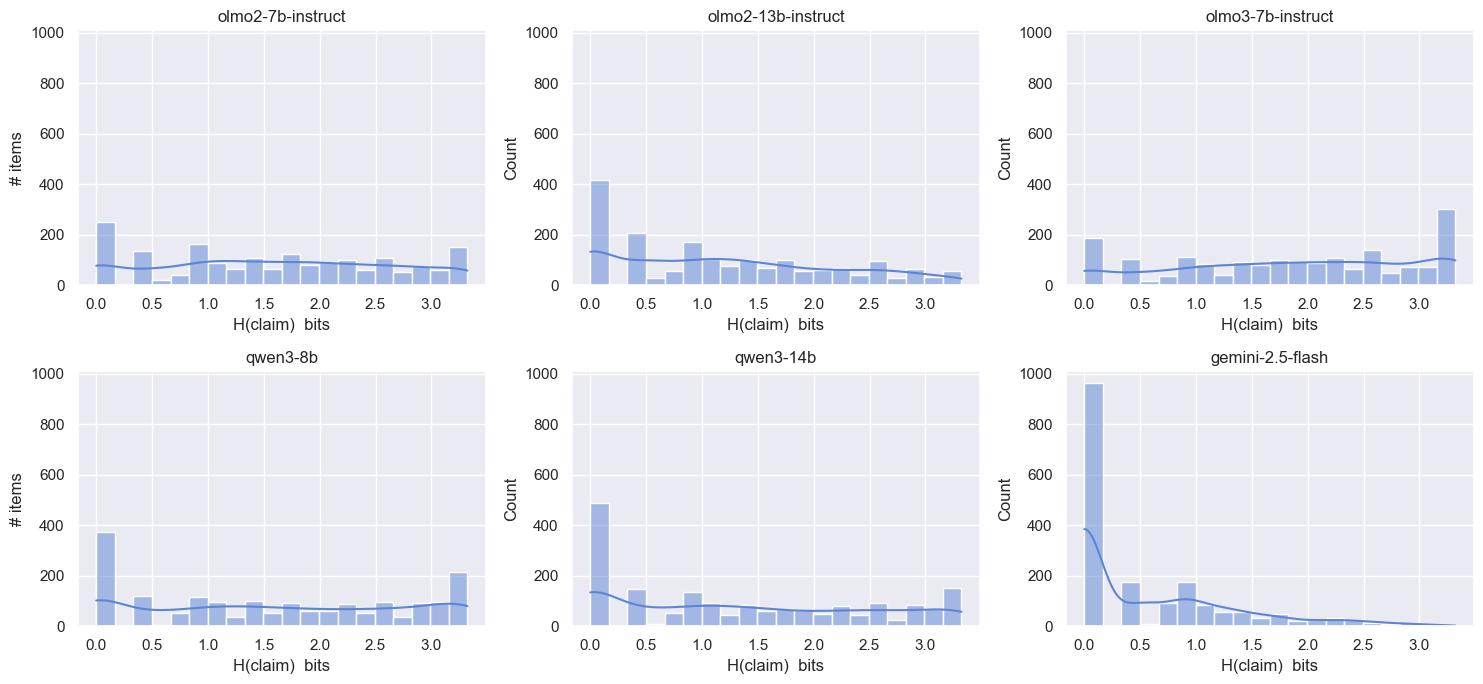

In [24]:
plot_variation_overview(df, config, cols=["h_claim"], dp="vanilla")

### Figure 5 — routing decisions vs belief-state entropy

Strategy composition (direct/clarify/abstain) as a function of H(claim), for SAG
(`prompt`) vs BAG (`belief`), on Qwen3-14B and Gemini-2.5-Flash — the two models
the paper highlights. BAG's clarify/abstain share should rise with entropy;
SAG's (prompt-only, no belief state) should not.

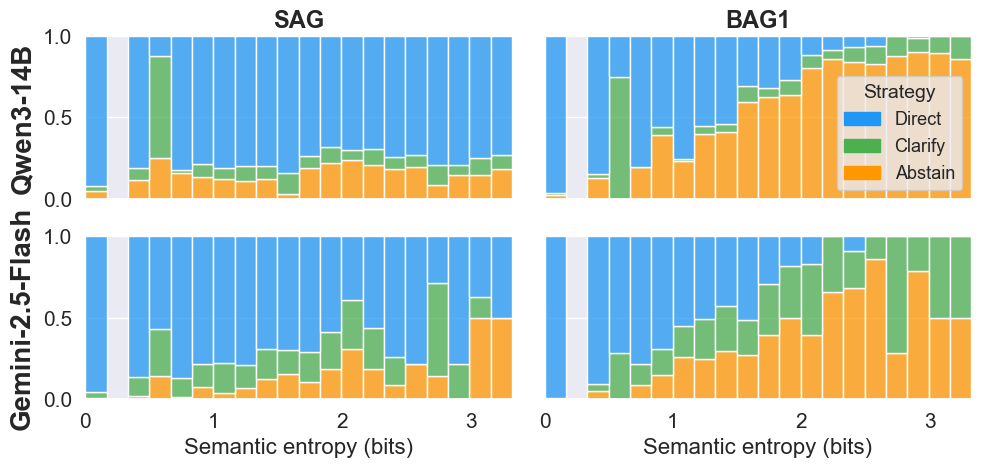

In [22]:
df_view, run_label = make_view(df_valid, config, settings=(
    ("qwen3-14b", "vanilla", ["prompt", "belief"]),
    ("gemini-2.5-flash", "vanilla", ["prompt", "belief"]),
))
plot_strategy_composition(df_view, "h_claims", run_label, fill=True)

### Figure 17 — uncertainty reduction after clarification

ΔH(claim) = H(claim) after the clarification turn minus before it (nan for
non-clarified items). Negative = clarification reduced factual uncertainty.
Paper §7, averaged across BAG1-3: Gemini -54%, Olmo2-13B -20%, Qwen3-14B -18%,
Qwen3-8B -16%, Olmo2-7B -14%, Olmo3-7B -1.7%.

In [25]:
clarified = fu_mod.print_entropy_reduction(df, config, dp="vanilla")

Items with delta_h_claim (vanilla): 1824 unique items

                    mean / belief  mean / belief6  mean / belief7  mean / BAG (avg)
assistant_model                                                                    
gemini-2.5-flash           -0.805          -0.744          -0.713            -0.754
olmo2-13b-instruct         -0.308          -0.287          -0.265            -0.287
olmo2-7b-instruct          -0.352          -0.255          -0.209            -0.272
olmo3-7b-instruct          -0.028          -0.109          -0.278            -0.138
qwen3-14b                  -0.482          -0.591          -0.505            -0.526
qwen3-8b                   -0.269          -0.507          -0.624            -0.467

% entropy reduction  (positive = reduced):
                    mean / belief  mean / belief6  mean / belief7  mean / BAG (avg)
assistant_model                                                                    
gemini-2.5-flash             56.9            49.1            

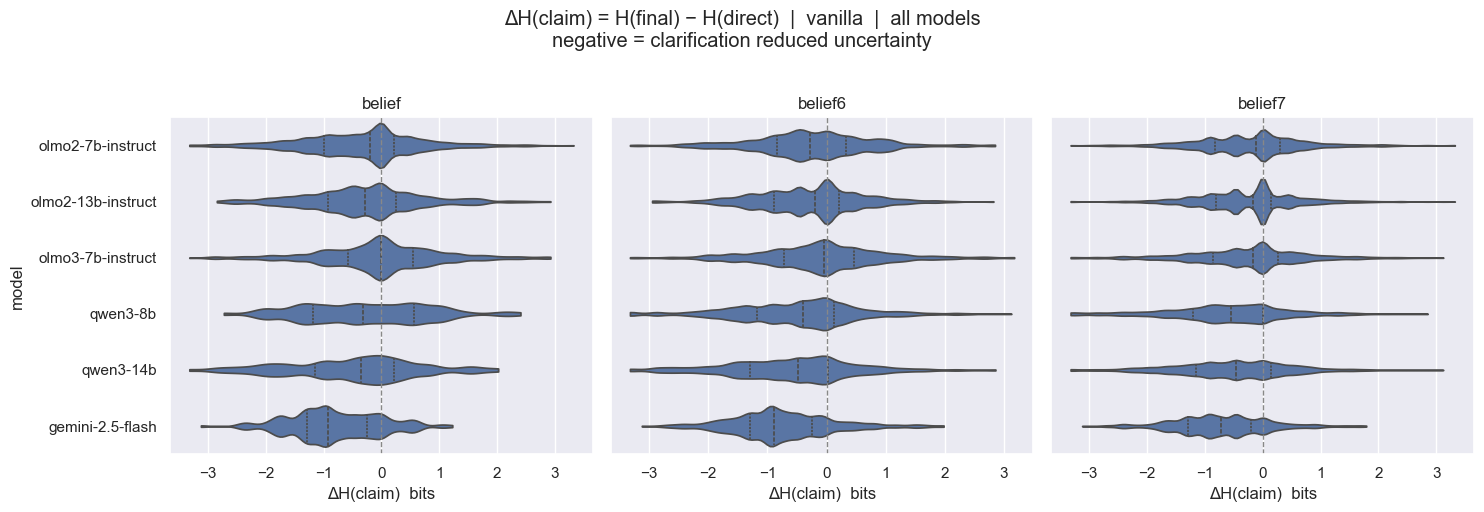

In [26]:
df_view, run_label = make_view(clarified, config, settings=[
    (am, "vanilla") for am in config["assistant_models"]
])
belief_rps = [rp for rp in rps if "belief" in rp]

fig, axes = plt.subplots(1, len(belief_rps), figsize=(5 * len(belief_rps), 5), sharey=True)
for ax, rp in zip(axes, belief_rps):
    sub = df_view[df_view.reasoner_prompt == rp]
    sns.violinplot(data=sub, x="delta_h_claim", y="assistant_model",
                   order=config["assistant_models"], inner="quartile", cut=0,
                   ax=ax, bw_adjust=0.4)
    ax.axvline(0, color="#888", linestyle="--", linewidth=1)
    ax.set(title=rp, xlabel="ΔH(claim)  bits", ylabel="")
axes[0].set_ylabel("model")
fig.suptitle(
    "ΔH(claim) = H(final) − H(direct)  |  vanilla  |  all models\nnegative = clarification reduced uncertainty",
    y=1.02,
)
plt.tight_layout()
plt.show()

## Exploratory analyses not in the paper

H(interpretation) or `interpretation_entropy()`), a binary contextualised-vs-not entropy 

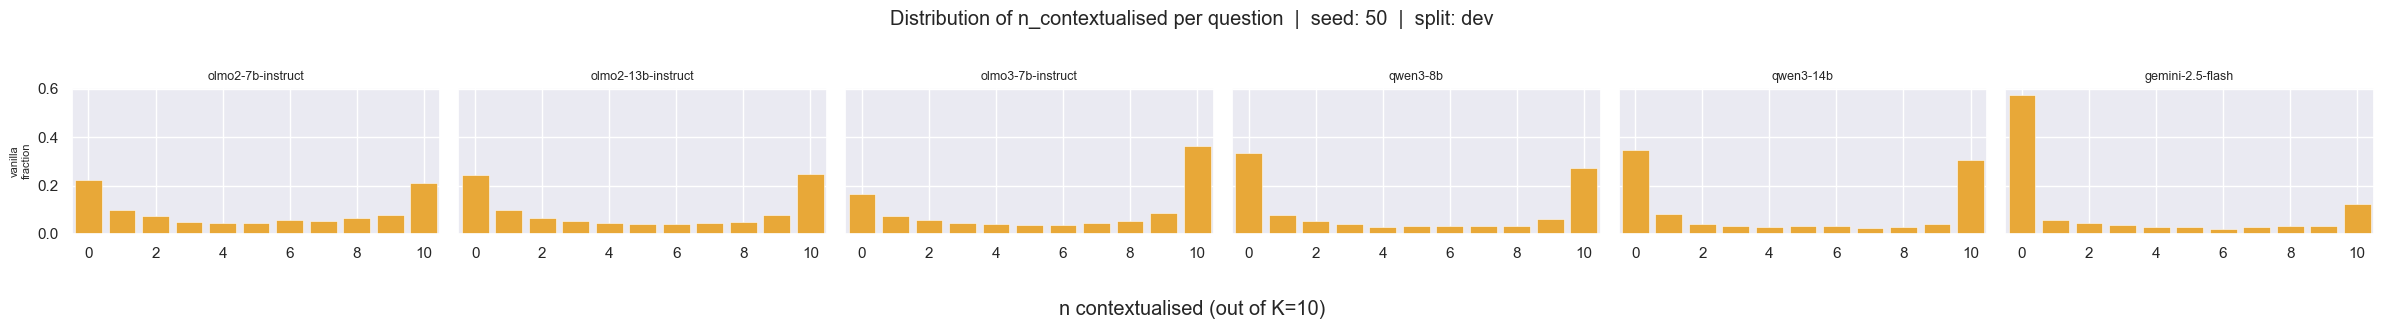

In [3]:
plot_n_contextualised_dist(df, config, dp="vanilla")

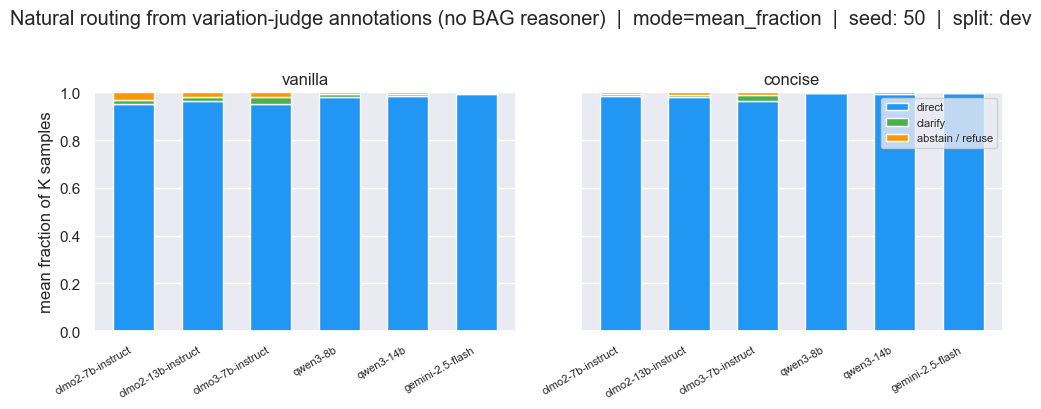


claim-variation judge  |  mode=mean_fraction
                                  clarify %  abstain/refuse %
model              direct_prompt                             
olmo2-7b-instruct  vanilla              1.9               3.0
olmo2-13b-instruct vanilla              1.7               1.9
olmo3-7b-instruct  vanilla              3.0               1.8
qwen3-8b           vanilla              1.2               0.7
qwen3-14b          vanilla              0.9               0.5
gemini-2.5-flash   vanilla              0.4               0.1
olmo2-7b-instruct  concise              0.6               0.8
olmo2-13b-instruct concise              1.0               1.0
olmo3-7b-instruct  concise              2.4               1.2
qwen3-8b           concise              0.3               0.2
qwen3-14b          concise              0.5               0.0
gemini-2.5-flash   concise              0.0               0.1


In [4]:
# plot_natural_routing(df, config, mode="at_least_one", judge="both")
plot_natural_routing(df, config, mode="mean_fraction", judge="cv")
# plot_natural_routing(df, config, mode="at_least_one", judge="cl")

## Claims vs interpretations: are the two signals correlated?

Spearman correlation + joint 2D heatmap per model. If correlated, they capture the same signal and shouldn't be treated as independent.

Though the marginal distributions appear simialr, their conditionals aren't, which means H(claim) and H(intern) fires for different questions.

In [27]:
# plot_signal_correlation(df, config)

## Distribution of routing decisions over claims or interpretations

In [28]:
# df_view, run_label = make_view(df_valid, config, model="olmo2-13b-instruct", dp="vanilla")
# plot_variation_by_strategy(df_view, rps, run_label, bw_adjust=0.1, metric="h", kind="violin")

## Strategy composition by n_distinct_interpretations

Stacked histogram: as the number of distinct (explicit) interpretations increases,
does clarify dominate? All models, vanilla prompt. Exploratory — uses H(interpretation),
not reported in the paper.

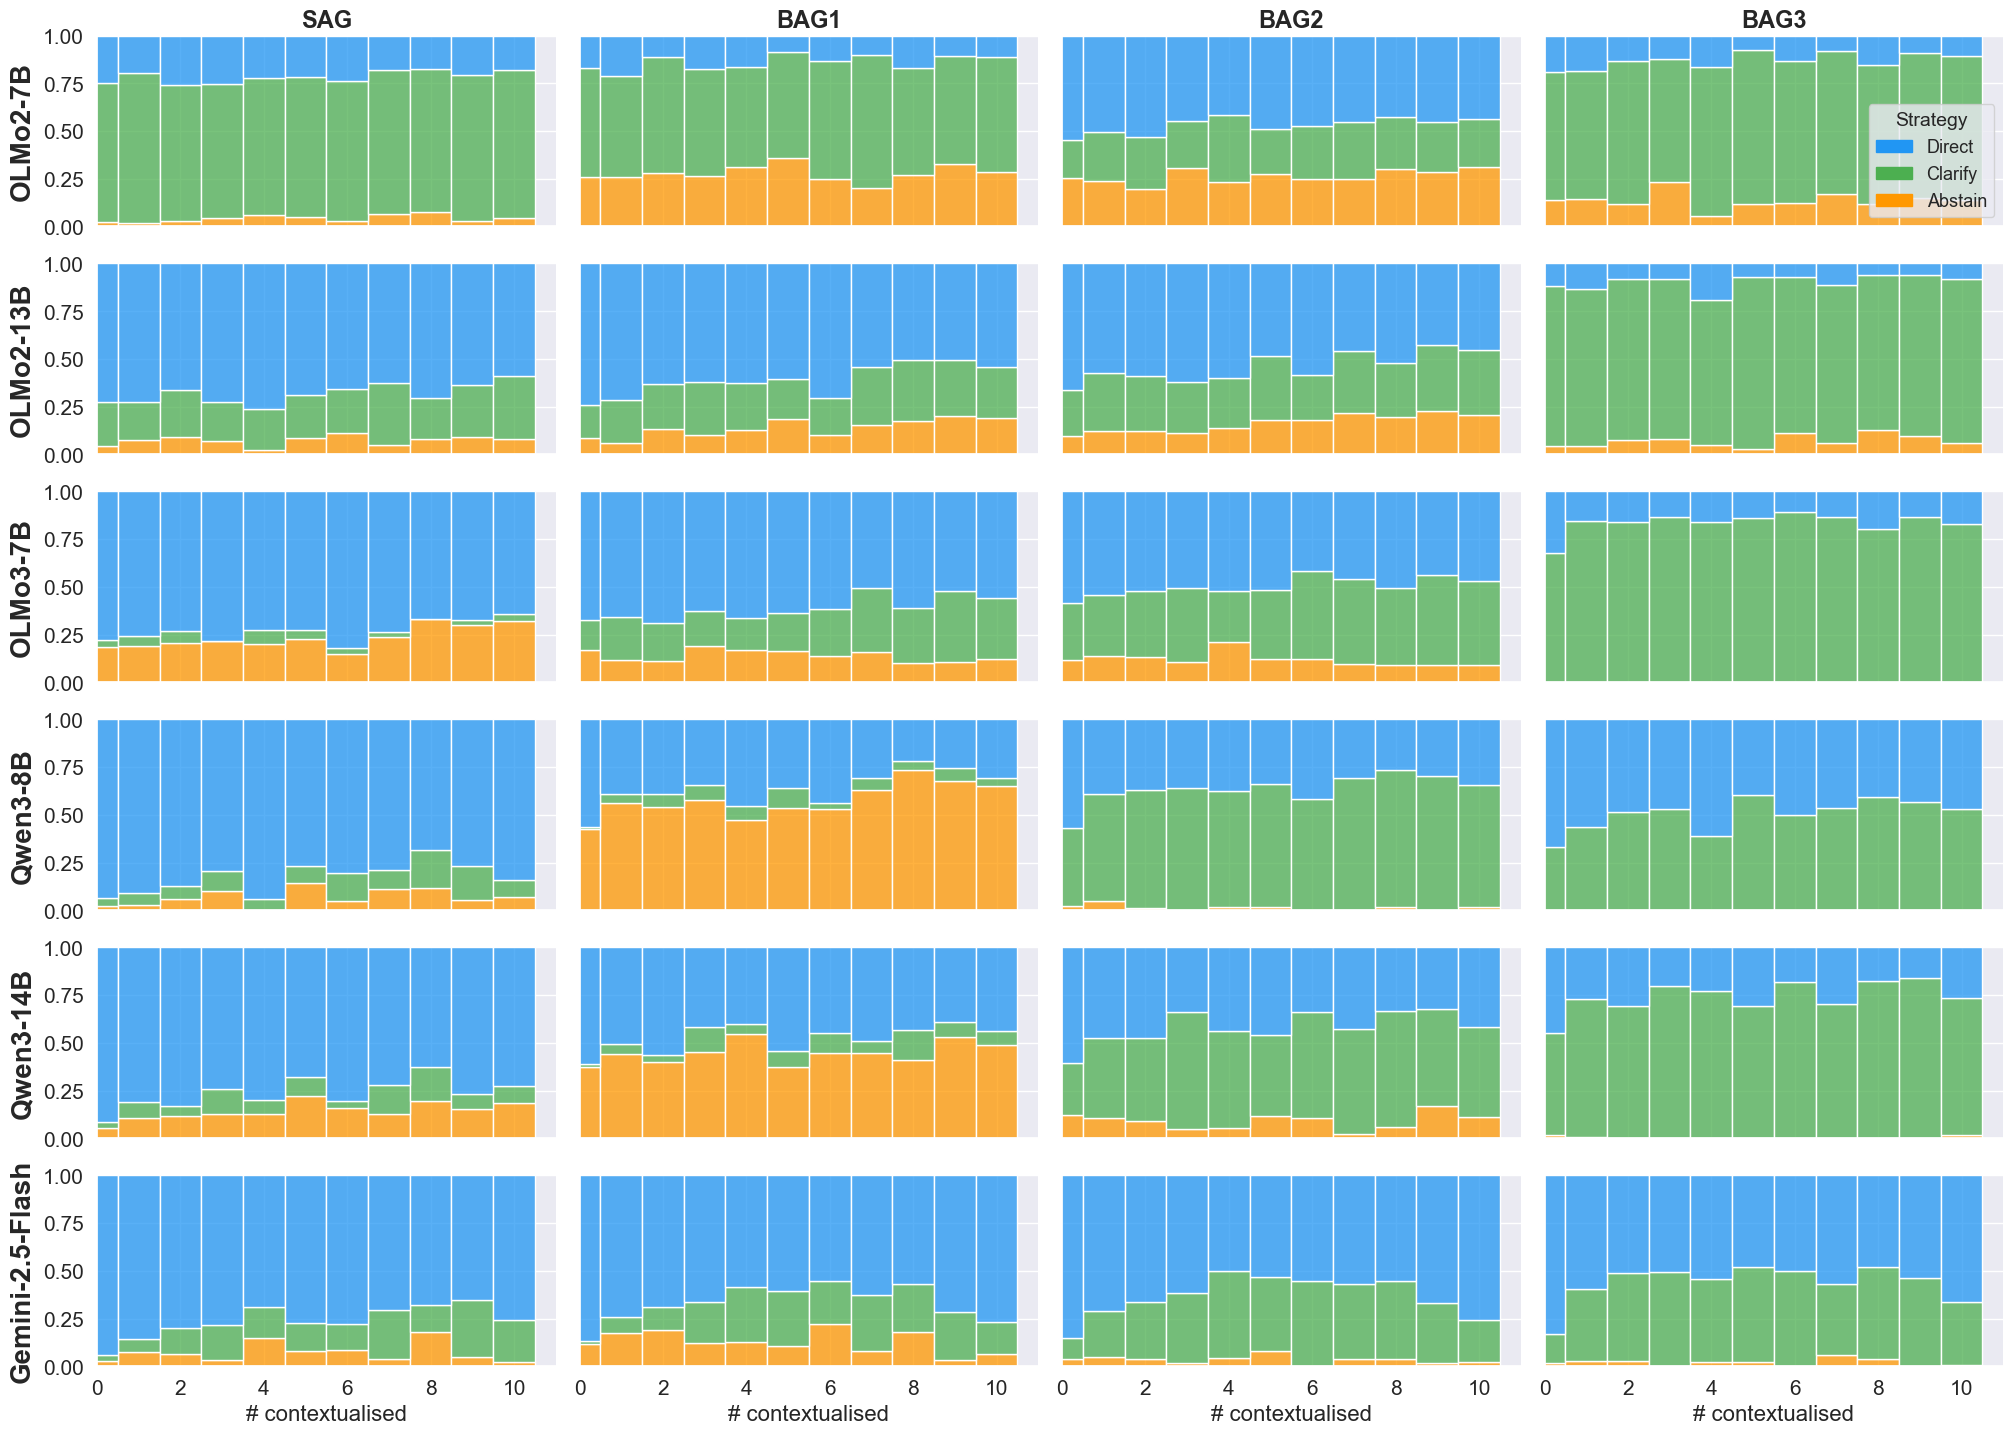

In [29]:
df_view, run_label = make_view(df_valid, config, settings=(
    ("olmo2-7b-instruct", "vanilla"),
    ("olmo2-13b-instruct", "vanilla"),
    ("olmo3-7b-instruct", "vanilla"),
    ("qwen3-8b", "vanilla"),
    ("qwen3-14b", "vanilla"),
    ("gemini-2.5-flash", "vanilla"),
))
plot_strategy_composition(df_view, "n_interp", run_label, fill=True)

## Scatter: H(claim) vs H(interpretation)

Tests the BAG routing hypothesis directly.
Each dot is one item coloured by the BAG reasoner's routing decision.

**`prompt` is the control**: it does not use the belief state.
If `prompt` shows the same quadrant separation as BAG methods, the pattern is
driven by question-level difficulty, not belief-state faithfulness.

In [30]:
# df_view, run_label = make_view(df_valid, config, model="gemini-2.5-flash", dp="vanilla")
# plot_entropy_scatter(df_view, rps, run_label, mode='kde', metric="binary")

## Quantitative faithfulness

For each reasoner prompt: what fraction of high-H(interp) items route to clarify,
and what fraction of high-H(claim) + low-H(interp) items route to abstain?
Thresholds are the medians across all items (excluding `prompt` baseline).

In [31]:
df_view, run_label = make_view(df_valid, config, model="gemini-2.5-flash", dp="vanilla")

_df_bag = df_view[df_view.reasoner_prompt != "prompt"].dropna(subset=["h_claim", "h_interpretation"])
h_claim_thr = _df_bag["h_claim"].median()
h_interp_thr = _df_bag["h_interpretation"].median()

rows_faith = []
for rp in rps:
    sub = df_view[df_view.reasoner_prompt == rp].dropna(subset=["h_claim", "h_interpretation"])
    hi_interp  = sub[sub.h_interpretation > h_interp_thr]
    hi_claim_lo_interp = sub[(sub.h_claim > h_claim_thr) & (sub.h_interpretation <= h_interp_thr)]
    rows_faith.append({
        "reasoner_prompt": rp,
        "clarify | high H(interp) %":        round(100 * (hi_interp.strategy == "clarification_question").mean(), 1),
        "abstain | high H(claim)+low H(interp) %": round(100 * (hi_claim_lo_interp.strategy == "abstain").mean(), 1),
        "n high_interp": len(hi_interp),
        "n hi_claim_lo_interp": len(hi_claim_lo_interp),
    })

df_faith = pd.DataFrame(rows_faith).set_index("reasoner_prompt")
print(f"Thresholds — H(claim): {h_claim_thr:.2f} bits  H(interp): {h_interp_thr:.2f} bits  (medians over BAG methods)\n")
print(df_faith.to_string())

Thresholds — H(claim): -0.00 bits  H(interp): -0.00 bits  (medians over BAG methods)

                 clarify | high H(interp) %  abstain | high H(claim)+low H(interp) %  n high_interp  n hi_claim_lo_interp
reasoner_prompt                                                                                                          
prompt                                 13.8                                      5.8            528                   536
belief                                 17.4                                     25.0            528                   536
belief6                                32.4                                      7.8            528                   536
belief7                                42.6                                      3.2            528                   536


In [32]:
df_view, run_label = make_view(df_valid, config, model="gemini-2.5-flash", dp="vanilla")
print_faithfulness_auroc(df_view, rps)

=== Faithfulness AUROC  (0.5 = chance, 1.0 = perfect) ===
                 AUROC H(interp)→clarify  AUROC H(claim)→abstain  AUROC consistency→direct
reasoner_prompt                                                                           
prompt                             0.572                   0.815                     0.761
belief                             0.657                   0.900                     0.915
belief6                            0.624                   0.911                     0.919
belief7                            0.625                   0.956                     0.900


## DIRECT routing with CQ/refusal belief states

Failure mode: belief state is mostly refusals or CQs, but no claim variation → routed to DIRECT.
`n_refusing_cv` / `n_clarifying_cv` from the claim_variation judge catch this directly.

In [33]:
df_view, run_label = make_view(df_valid, config, model="gemini-2.5-flash", dp="vanilla")

rows_leak = []
for rp in rps:
    sub = df_view[df_view.reasoner_prompt == rp]
    directs = sub[sub.strategy == "direct_answer"]
    n = len(directs)
    if n == 0:
        continue
    rows_leak.append({
        "reasoner_prompt": rp,
        "n DIRECT": n,
        "any refusal %": round(100 * (directs.n_refusing_cv > 0).mean(), 1),
        "maj refusal %": round(100 * (directs.n_refusing_cv >= 5).mean(), 1),
        "any CQ %":      round(100 * (directs.n_clarifying_cv > 0).mean(), 1),
    })

print(pd.DataFrame(rows_leak).set_index("reasoner_prompt").to_string())

                 n DIRECT  any refusal %  maj refusal %  any CQ %
reasoner_prompt                                                  
prompt               1579            0.1            0.0       0.9
belief               1450            0.1            0.0       0.7
belief6              1407            0.1            0.0       0.4
belief7              1320            0.1            0.0       0.5


## Calibration: entropy → routing probability

Does each entropy signal monotonically predict its target routing decision?
`prompt` (dashed) is the null hypothesis — it doesn't see the belief state.
BAG methods should show a rising slope; `prompt` should be flat.

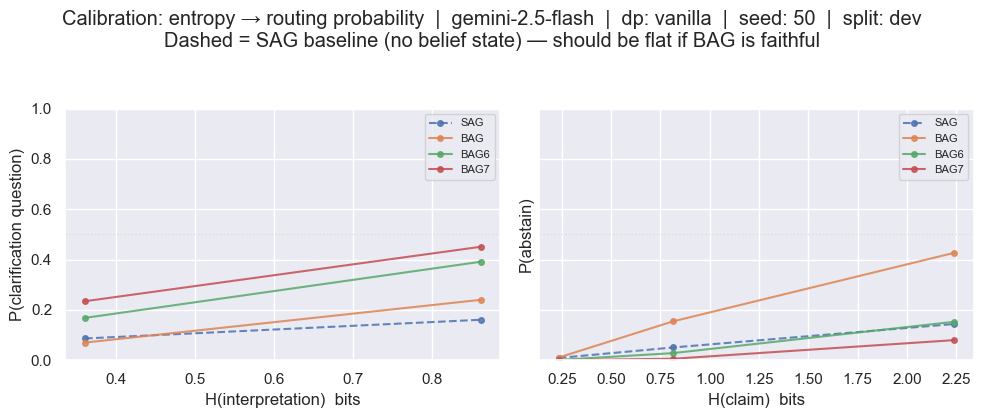

In [34]:
df_view, run_label = make_view(df_valid, config, model="gemini-2.5-flash", dp="vanilla")
plot_calibration(df_view, rps, run_label)

## Quadrant breakdown

Items split into four quadrants by median H(claim) and H(interp).
Shows how often each quadrant occurs and which strategy dominates there.
BAG hypothesis: Q1→direct, Q2→clarify, Q3→abstain, Q4 is the ambiguous case.

In [35]:
df_view, run_label = make_view(df_valid, config, model="gemini-2.5-flash", dp="vanilla")

_df_q = df_view.dropna(subset=["h_claim", "h_interpretation"]).copy()
_bag  = _df_q[_df_q.reasoner_prompt != "prompt"]
_hc   = _bag["h_claim"].median()
_hi   = _bag["h_interpretation"].median()

_df_q["quadrant"] = np.select(
    [(_df_q.h_claim <= _hc) & (_df_q.h_interpretation <= _hi),
     (_df_q.h_claim <= _hc) & (_df_q.h_interpretation >  _hi),
     (_df_q.h_claim >  _hc) & (_df_q.h_interpretation <= _hi),
     (_df_q.h_claim >  _hc) & (_df_q.h_interpretation >  _hi)],
    ["Q1 low-claim  low-interp  → direct",
     "Q2 low-claim  high-interp → clarify",
     "Q3 high-claim low-interp  → abstain",
     "Q4 high-claim high-interp → mixed"],
)
print(pd.crosstab(_df_q.quadrant, _df_q.reasoner_prompt,
                  values=(_df_q.strategy == "clarification_question").astype(float),
                  aggfunc="mean", margins=False).round(2).to_string(),
      "\n(cell = P(clarify))\n")
print(pd.crosstab(_df_q.quadrant, _df_q.reasoner_prompt).to_string(), "\n(cell = n items)")

reasoner_prompt                      belief  belief6  belief7  prompt
quadrant                                                             
Q1 low-claim  low-interp  → direct     0.00     0.00     0.01    0.03
Q2 low-claim  high-interp → clarify    0.01     0.02     0.05    0.07
Q3 high-claim low-interp  → abstain    0.14     0.35     0.46    0.15
Q4 high-claim high-interp → mixed      0.27     0.50     0.64    0.18 
(cell = P(clarify))

reasoner_prompt                      belief  belief6  belief7  prompt
quadrant                                                             
Q1 low-claim  low-interp  → direct      768      768      768     768
Q2 low-claim  high-interp → clarify     193      193      193     193
Q3 high-claim low-interp  → abstain     536      536      536     536
Q4 high-claim high-interp → mixed       335      335      335     335 
(cell = n items)


## Entropy signals vs direct answer quality

Validates the signals: does H(claim) predict that the direct answer is wrong?
Does H(interp) also predict low direct quality (ambiguous questions have no single correct answer)?
Direct quality is independent of the reasoner prompt — one value per item.

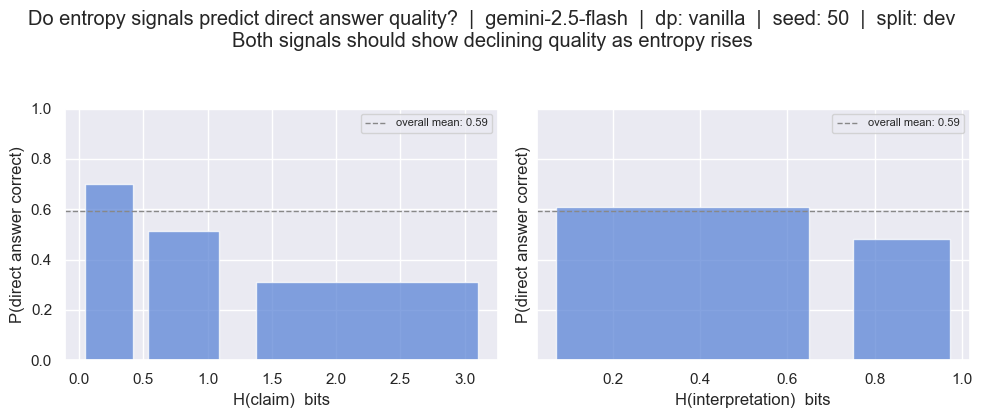

In [36]:
df_view, run_label = make_view(df_valid, config, model="gemini-2.5-flash", dp="vanilla")

_df_qual = df_view[df_view.reasoner_prompt == rps[0]].copy()
_df_qual["direct_verdict"] = _df_qual.apply(
    lambda r: judge_data.get((r.assistant_model, r.direct_prompt, r.belief_sampling), {}).get(r.item_id, {}).get("direct", -1),
    axis=1,
)
_df_qual = _df_qual[_df_qual.direct_verdict >= 0]  # drop unparseable

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (xcol, xlabel) in zip(axes, [
    ("h_claim",          "H(claim)  bits"),
    ("h_interpretation", "H(interpretation)  bits"),
]):
    sub = _df_qual.dropna(subset=[xcol]).copy()
    sub["_bin"] = pd.qcut(sub[xcol], q=5, duplicates="drop")
    binned = sub.groupby("_bin", observed=True)["direct_verdict"].mean()
    ax.bar([iv.mid for iv in binned.index], binned.values,
           width=[iv.length * 0.8 for iv in binned.index],
           color="#5C85D6", alpha=0.75, edgecolor="white")
    ax.set(xlabel=xlabel, ylabel="P(direct answer correct)", ylim=(0, 1))
    ax.axhline(sub.direct_verdict.mean(), color="#888", linestyle="--",
               linewidth=1, label=f"overall mean: {sub.direct_verdict.mean():.2f}")
    ax.legend(fontsize=8)

fig.suptitle(
    f"Do entropy signals predict direct answer quality?  |  {run_label}\n"
    "Both signals should show declining quality as entropy rises",
    y=1.04,
)
plt.tight_layout()
plt.show()

In [37]:
df_view, run_label = make_view(df_valid, config, model="gemini-2.5-flash", dp="vanilla")
print_quality_auroc(df_view, rps, judge_data)

=== Quality AUROC  (n=1832, 0.5 = chance, 1.0 = perfect) ===
                      AUROC
signal                     
-H(claim) → correct   0.679
-H(interp) → correct  0.571


## Entropy CDFs by strategy

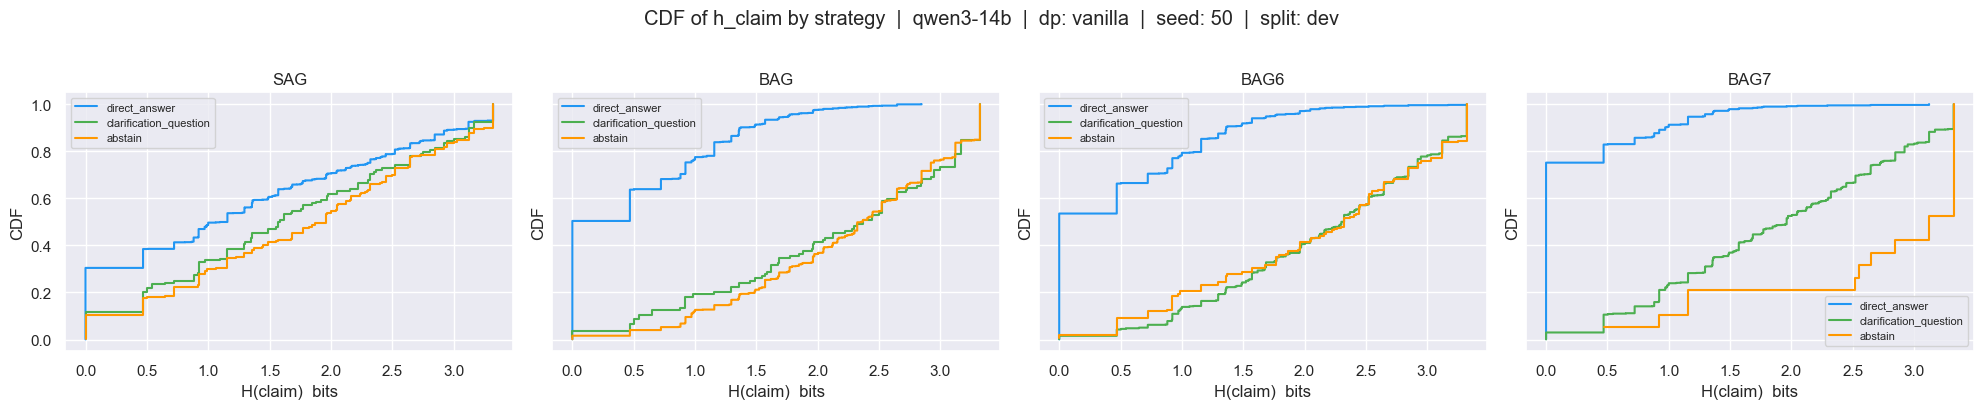

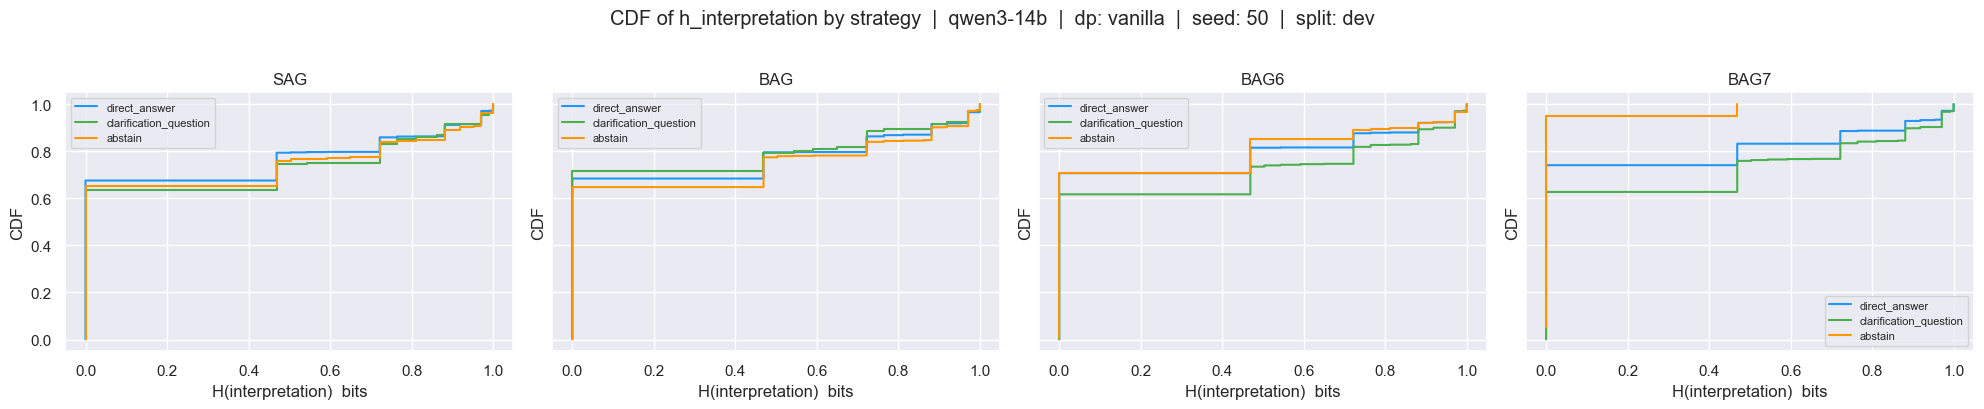

In [38]:
df_view, run_label = make_view(df_valid, config, model="qwen3-14b", dp="vanilla")
plot_entropy_cdfs(df_view, rps, run_label)

## Belief-state length vs diversity

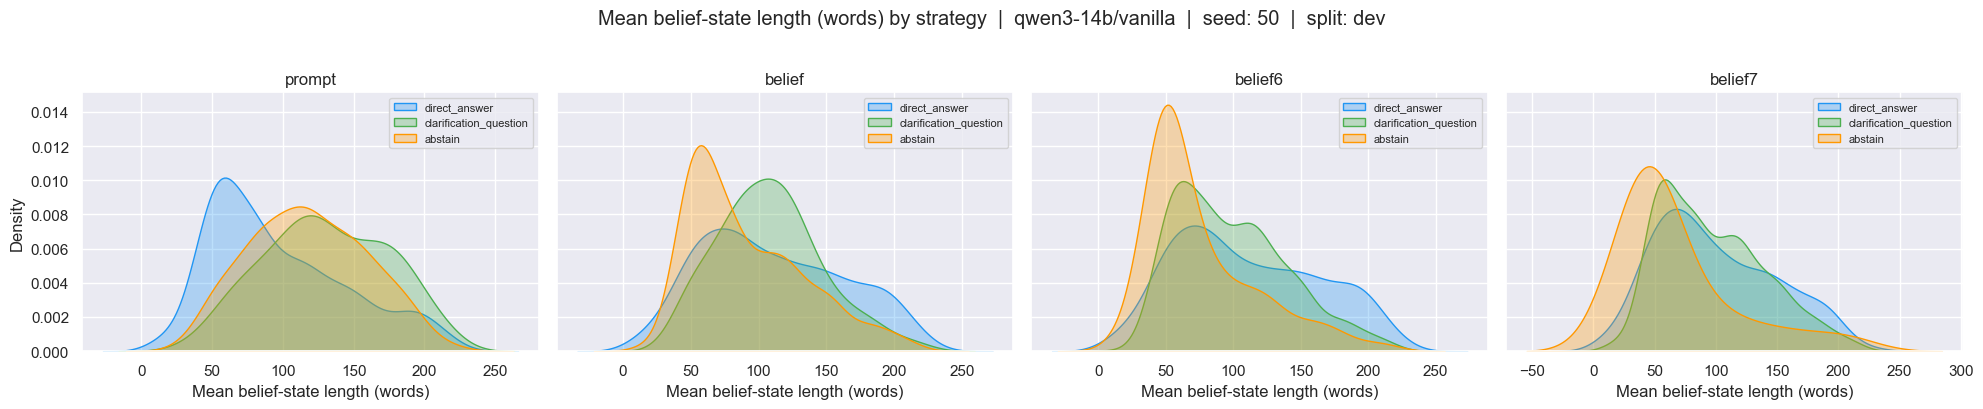

In [39]:
from faithfulness_utils import kde_by_strategy
df_view, run_label = make_view(df_valid, config, settings=(
    ("qwen3-14b", "vanilla"),
    # ("gemini-2.5-flash", "vanilla"),
)
                               )

for col, xlabel in [
    ("mean_belief_len", "Mean belief-state length (words)"),
    # ("std_belief_len",  "Std of belief-state length (words)"),
]:
    df_len = df_view.dropna(subset=[col]).copy()
    fig, axes = rp_axes(rps, figsize=(5 * len(rps), 4), sharey=True)
    for ax, rp in zip(axes, rps):
        kde_by_strategy(ax, df_len[df_len.reasoner_prompt == rp], col)
        ax.set(title=rp, xlabel=xlabel)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Density")
    fig.suptitle(f"{xlabel} by strategy  |  {run_label}", y=1.02)
    plt.tight_layout()
    plt.show()